# Couinaud Liver Segmentation → NPZ Conversion and Visualization

This notebook converts the **Couinaud Liver Segmentation** dataset (NIfTI)
into the unified `.npz` format used by the Prompt U-Net pipeline.

## Dataset overview
- **Source**: MSD Task08 Hepatic Vessel CT scans (303 volumes) with
  Couinaud liver segment labels (161 annotated).
- **Images**: Abdominal CT, HU-calibrated, originally 512×512 px in-plane,
  downsampled to 256×256 to keep the NPZ memory footprint manageable.
- **Masks**: 8 Couinaud liver segments (I–VIII) as label values 1–8,
  background = 0.
- **Format**: NIfTI `.nii.gz` → downloaded on-demand from HuggingFace
  (`Angelou0516/couinaud-liver` + `Angelou0516/msd-hepatic-vessel`).
- **Label map**: 0 = Background, 1–8 = Couinaud segments I–VIII
- **Modality**: CT (HU path in `universal_normalization`)

## 0. Imports & path setup

In [1]:
import os
import sys
import numpy as np
from pathlib import Path

# Suppress obnoxious HF symlink warning on Windows
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

# Add project root to sys.path
project_root = str(Path().resolve().parent.parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from data.test_data.couinaud_to_npz import process_couinaud_dataset, LABEL_MAP, MODALITY
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices

print("Project root:", project_root)
print("Modality:", MODALITY)
print("Label map:", dict(LABEL_MAP))

2026-05-19 10:06:10.884478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779177970.918270      65 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779177970.925825      65 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-19 10:06:10.954873: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Project root: /home/dpxuser/prompt-unet
Modality: CT
Label map: {0: 'Background', 1: 'Caudate lobe (I)', 2: 'Left lateral superior segment (II)', 3: 'Left lateral inferior segment (III)', 4: 'Left medial segment (IV)', 5: 'Right anterior inferior segment (V)', 6: 'Right posterior inferior segment (VI)', 7: 'Right posterior superior segment (VII)', 8: 'Right anterior superior segment (VIII)'}


## 1. Download a single sample & inspect

Before converting the full dataset, let's pull one volume from HuggingFace
and inspect the raw NIfTI data.

Image  shape=(59, 512, 512)  dtype=float64   HU=[-1024, 1313]
Mask   shape=(59, 512, 512)  dtype=float64
Mask labels: [1. 2. 3. 4. 5. 6. 7. 8.]


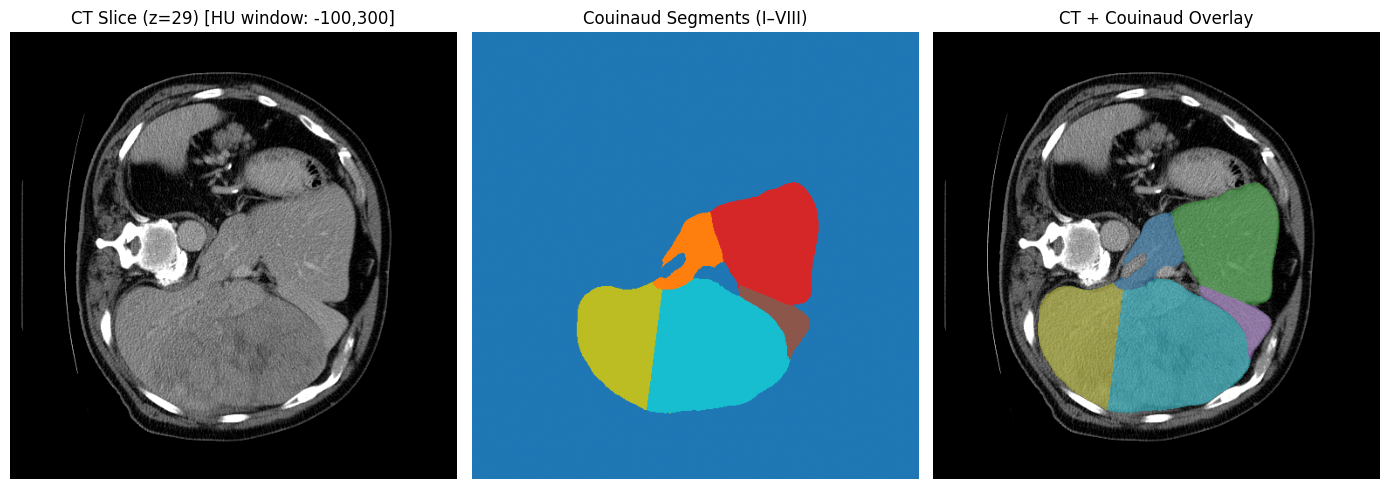

In [2]:
import nibabel as nib
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt

# Download one mask + one image
mask_path = hf_hub_download(
    'Angelou0516/couinaud-liver',
    'hepaticvessel_025.nii.gz',
    repo_type='dataset'
)
img_path = hf_hub_download(
    'Angelou0516/msd-hepatic-vessel',
    'imagesTr/hepaticvessel_025.nii.gz',
    repo_type='dataset'
)

mask = nib.load(mask_path).get_fdata()  # (X, Y, Z)
img  = nib.load(img_path).get_fdata()   # (X, Y, Z)

# Transpose to (Z, H, W) for display
mask = np.transpose(mask, (2, 0, 1))
img  = np.transpose(img,  (2, 0, 1))

print(f"Image  shape={img.shape}  dtype={img.dtype}   HU=[{img.min():.0f}, {img.max():.0f}]")
print(f"Mask   shape={mask.shape}  dtype={mask.dtype}")
print(f"Mask labels: {np.setdiff1d(np.unique(mask), [0])}")

mid_z = img.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img[mid_z],  cmap='gray', vmin=-100, vmax=300)
axes[0].set_title(f'CT Slice (z={mid_z}) [HU window: -100,300]')
axes[0].axis('off')
axes[1].imshow(mask[mid_z], cmap='tab10', vmin=0, vmax=8)
axes[1].set_title('Couinaud Segments (I–VIII)')
axes[1].axis('off')
axes[2].imshow(img[mid_z],  cmap='gray', vmin=-100, vmax=300)
axes[2].imshow(np.ma.masked_equal(mask[mid_z], 0), cmap='tab10', vmin=1, vmax=8, alpha=0.5)
axes[2].set_title('CT + Couinaud Overlay')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## 2. Convert the dataset to .npz

Run `process_couinaud_dataset` to download from HuggingFace, pair images
and masks, and save as a single `.npz` file.

> **Note**: The first run downloads ~40 CT volumes from HuggingFace
> (~15–25 MB each, ~1 GB total).  Subsequent runs use cached files.

In [ ]:
script_dir = os.path.abspath('')  # notebook directory
output_name = 'couinaud_liver'
out_path    = os.path.join(script_dir, output_name)

process_couinaud_dataset(
    output_path=out_path,
    max_volumes=40,
    cache_dir=os.path.join(script_dir, '_couinaud_cache'),
)

  Fetching JSONL from Angelou0516/couinaud-liver …
  JSONL entries: 161
  [1/40] hepaticvessel_025  shape=(59, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 1313]


  [2/40] hepaticvessel_235  shape=(38, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 1274]
  [3/40] hepaticvessel_031  shape=(108, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 1254]
  [4/40] hepaticvessel_051  shape=(34, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 1284]
  [5/40] hepaticvessel_085  shape=(36, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 1585]
  [6/40] hepaticvessel_032  shape=(60, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 3072]
  [7/40] hepaticvessel_147  shape=(58, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 1382]
  [8/40] hepaticvessel_066  shape=(49, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 1538]
  [9/40] hepaticvessel_010  shape=(49, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 982]
  [10/40] hepaticvessel_353  shape=(56, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 1488]
  [11/40] hepaticvessel_001  shape=(49, 512, 512)  labels=[1, 2, 3, 4, 5, 6, 7, 8]  HU=[-1024, 1289

## 3. Load the .npz and inspect via DataGenerator

In [2]:
output_name = 'couinaud_liver'
npz_relative = f'data/test_data/{output_name}.npz'
full_npz_path = os.path.join(project_root, npz_relative)

print("Loading:", full_npz_path)

dg = DataGenerator(DataLoader_npz([full_npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids

print(f"\nLoaded {len(all_ids)} volumes.")
print("First 10 IDs:", all_ids[:10])

Loading: /home/dpxuser/prompt-unet/data/test_data/couinaud_liver.npz

Loading NPZ dataset(s)…
Loaded 40 PIDs from /home/dpxuser/prompt-unet/data/test_data/couinaud_liver.npz

Final dataset size: 40 patients.


Loaded 40 volumes.
First 10 IDs: ['couinaud_liver_hepaticvessel_235', 'couinaud_liver_hepaticvessel_175', 'couinaud_liver_hepaticvessel_013', 'couinaud_liver_hepaticvessel_115', 'couinaud_liver_hepaticvessel_066', 'couinaud_liver_hepaticvessel_147', 'couinaud_liver_hepaticvessel_369', 'couinaud_liver_hepaticvessel_445', 'couinaud_liver_hepaticvessel_329', 'couinaud_liver_hepaticvessel_051']


In [3]:
# Inspect a single volume
sample_id = all_ids[0]
entry     = dg.dataloader.dataset[sample_id]

vol  = entry['image']           # (Z, 256, 256) float32
segs = entry['segmentations']   # (Z, 256, 256) uint8
seg  = segs[0] if isinstance(segs, (list, tuple)) else segs

# Per-segment statistics
for lbl, name in LABEL_MAP.items():
    if lbl == 0:
        continue
    count = int(np.sum(seg == lbl))
    frac  = 100 * count / seg.size
    print(f"  {name:45s}  {count:>10d} voxels  ({frac:.2f} %)")

print(f"\nVolume       : {sample_id}")
print(f"Image shape  : {vol.shape}  dtype={vol.dtype}")
print(f"Seg shape    : {seg.shape}  dtype={seg.dtype}")
print(f"Total liver  : {int(np.sum(seg > 0))} / {seg.size}  ({100*np.mean(seg > 0):.2f} %)")
print(f"HU range     : [{vol.min():.0f}, {vol.max():.0f}]")
print(f"Modality     : {entry['modality']}")

  Caudate lobe (I)                                    36116 voxels  (0.36 %)
  Left lateral superior segment (II)                  70570 voxels  (0.71 %)
  Left lateral inferior segment (III)                 24261 voxels  (0.24 %)
  Left medial segment (IV)                            73577 voxels  (0.74 %)
  Right anterior inferior segment (V)                 93369 voxels  (0.94 %)
  Right posterior inferior segment (VI)               77661 voxels  (0.78 %)
  Right posterior superior segment (VII)              88986 voxels  (0.89 %)
  Right anterior superior segment (VIII)             141706 voxels  (1.42 %)

Volume       : couinaud_liver_hepaticvessel_235
Image shape  : (38, 512, 512)  dtype=float32
Seg shape    : (38, 512, 512)  dtype=uint8
Total liver  : 606246 / 9961472  (6.09 %)
HU range     : [-1024, 1274]
Modality     : CT


## 4. Visualize: 9-slice overview grid

We plot 9 equally spaced slices along the Z-axis with Couinaud segment overlays.

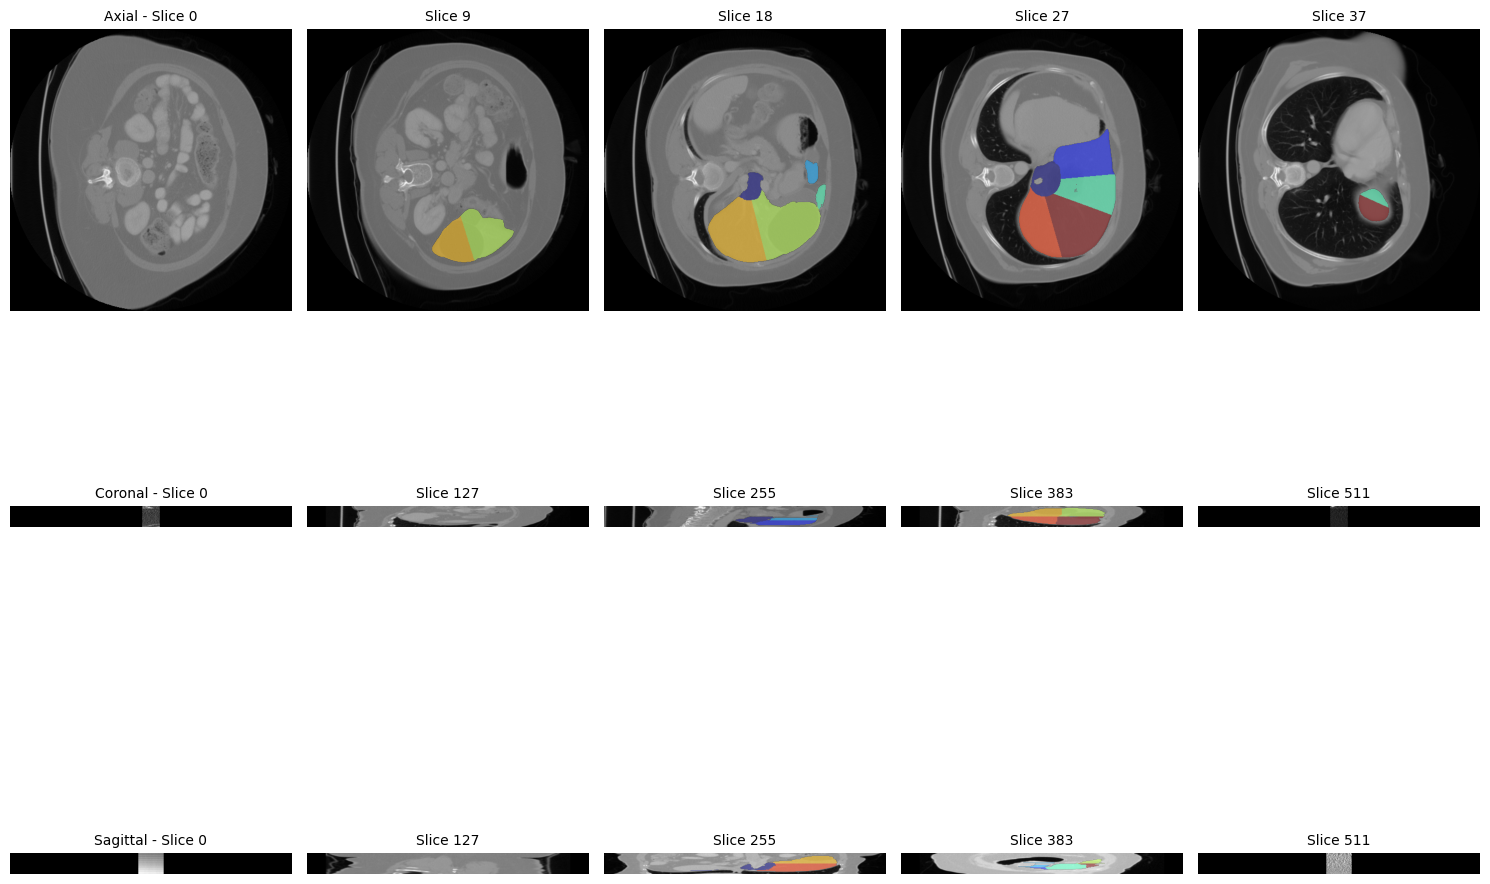

In [4]:
plot_vol_slices(vol, seg)

## 5. Visualize: side-by-side comparison across volumes

Pick the middle slice for each of the first 5 volumes to compare liver sizes
and Couinaud segment distributions.

In [5]:
from matplotlib import pyplot as plt

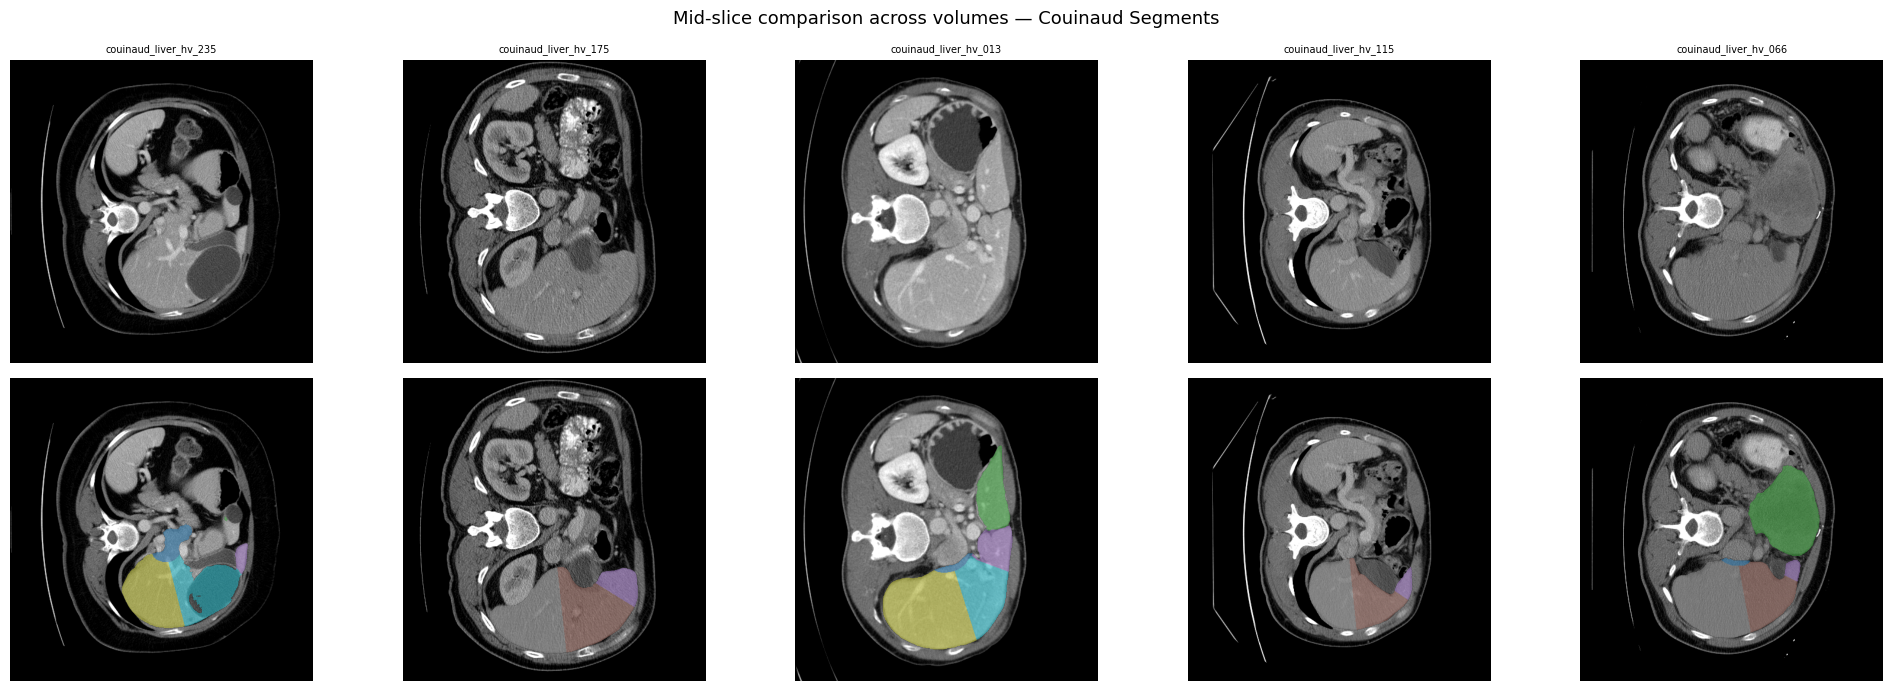

In [6]:
n_volumes = min(5, len(all_ids))
fig, axes = plt.subplots(2, n_volumes, figsize=(20, 7))
fig.suptitle("Mid-slice comparison across volumes — Couinaud Segments", fontsize=13)

for col, sid in enumerate(all_ids[:n_volumes]):
    e = dg.dataloader.dataset[sid]
    v = e['image']
    s = e['segmentations']
    if isinstance(s, (list, tuple)):
        s = s[0]

    mid_z = v.shape[0] // 2

    axes[0, col].imshow(v[mid_z], cmap='gray', vmin=-100, vmax=300)
    axes[0, col].set_title(sid.replace('hepaticvessel_', 'hv_')[:25], fontsize=7)
    axes[0, col].axis('off')

    axes[1, col].imshow(v[mid_z], cmap='gray', vmin=-100, vmax=300)
    axes[1, col].imshow(
        np.ma.masked_equal(s[mid_z], 0),
        cmap='tab10', vmin=1, vmax=8, alpha=0.5
    )
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Image (CT)', fontsize=9)
axes[1, 0].set_ylabel('CT + Couinaud labels', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Dataset statistics summary

Number of volumes         : 40
Slices per volume         : min=34  max=174  mean=66.2
Liver voxel fraction      : min=2.50%  max=7.77%  mean=4.97%

Per-segment average voxel counts:
  [1] Caudate lobe (I)                               mean=39050  min=9535  max=109215
  [2] Left lateral superior segment (II)             mean=102734  min=31764  max=266545
  [3] Left lateral inferior segment (III)            mean=53600  min=13749  max=211962
  [4] Left medial segment (IV)                       mean=92793  min=23257  max=328745
  [5] Right anterior inferior segment (V)            mean=125884  min=15168  max=462928
  [6] Right posterior inferior segment (VI)          mean=114391  min=2236  max=428856
  [7] Right posterior superior segment (VII)         mean=154710  min=32403  max=568450
  [8] Right anterior superior segment (VIII)         mean=180991  min=51742  max=584602


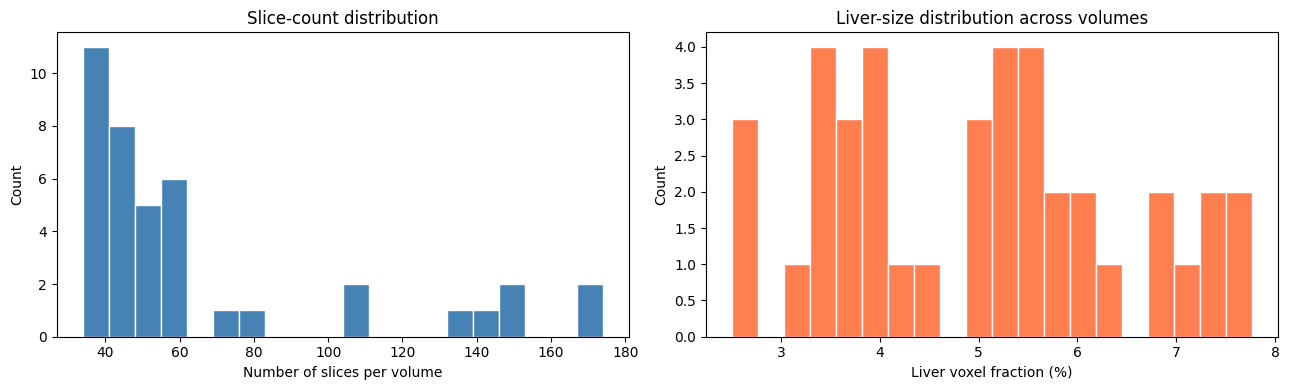

In [7]:
slice_counts = []
liver_fracs  = []
per_segment_counts = {lbl: [] for lbl in range(1, 9)}

for sid in all_ids:
    e = dg.dataloader.dataset[sid]
    v = e['image']
    s = e['segmentations']
    if isinstance(s, (list, tuple)):
        s = s[0]
    slice_counts.append(v.shape[0])
    liver_fracs.append(np.mean(s > 0))
    for lbl in range(1, 9):
        per_segment_counts[lbl].append(int(np.sum(s == lbl)))

print(f"Number of volumes         : {len(all_ids)}")
print(f"Slices per volume         : min={min(slice_counts)}  max={max(slice_counts)}  mean={np.mean(slice_counts):.1f}")
print(f"Liver voxel fraction      : min={min(liver_fracs)*100:.2f}%  max={max(liver_fracs)*100:.2f}%  mean={np.mean(liver_fracs)*100:.2f}%")
print()
print("Per-segment average voxel counts:")
for lbl in range(1, 9):
    name = LABEL_MAP[lbl]
    vals = per_segment_counts[lbl]
    print(f"  [{lbl}] {name:45s}  mean={np.mean(vals):.0f}  min={np.min(vals)}  max={np.max(vals)}")

# Histograms
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(slice_counts, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Number of slices per volume")
axes[0].set_ylabel("Count")
axes[0].set_title("Slice-count distribution")

axes[1].hist([f*100 for f in liver_fracs], bins=20, color='coral', edgecolor='white')
axes[1].set_xlabel("Liver voxel fraction (%)")
axes[1].set_ylabel("Count")
axes[1].set_title("Liver-size distribution across volumes")

plt.tight_layout()
plt.show()